# "Double pendulum simulation from scratch"

## libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

## Physical parameters:

In [2]:
m1 = 10.0  # mass of first bob
m2 = 1.0  # mass of second bob
L1 = 2.0  # length of first arm
L2 = 0.5  # length of second arm
g = 9.81  # gravitational acceleration

## eqautions:

In [3]:
def derivatives(state, t):
    
    theta1, theta2, omega1, omega2 = state
    
    # Differences
    dtheta = theta2 - theta1
    
    # Trigonometric functions
    sin_dtheta = np.sin(dtheta)
    cos_dtheta = np.cos(dtheta)
    sin_theta1 = np.sin(theta1)
    sin_theta2 = np.sin(theta2)
    
    # Denominator
    denom = (m1 + m2) * L1 - m2 * L1 * cos_dtheta * cos_dtheta
    
    # Angular accelerations
    alpha1 = (
        m2 * L1 * omega1**2 * sin_dtheta * cos_dtheta +
        m2 * g * np.sin(theta2) * cos_dtheta +
        m2 * L2 * omega2**2 * sin_dtheta -
        (m1 + m2) * g * sin_theta1
    ) / denom
    
    alpha2 = (
        -m2 * L2 * omega2**2 * sin_dtheta * cos_dtheta +
        (m1 + m2) * (g * sin_theta1 * cos_dtheta - L1 * omega1**2 * sin_dtheta - g * sin_theta2)
    ) / (m2 * L2 * denom)
    
    return [omega1, omega2, alpha1, alpha2]

## Deffrential equation solver:

In [4]:
def rk4_step(state, t, dt):
    k1 = np.array(derivatives(state, t))
    k2 = np.array(derivatives(state + 0.5 * dt * k1, t + 0.5 * dt))
    k3 = np.array(derivatives(state + 0.5 * dt * k2, t + 0.5 * dt))
    k4 = np.array(derivatives(state + dt * k3, t + dt))
    
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

## Simulation parameters:

In [5]:
dt = 0.01  # time step
t_end = 20.0  # total simulation time
t_steps = int(t_end / dt)

### Initial conditions:
#### theta1, theta2 (angles from vertical), omega1, omega2 (angular velocities)

In [9]:
initial_state = np.array([np.pi/2, np.pi/2.5, 1.0, -2.0])

## Run simulation

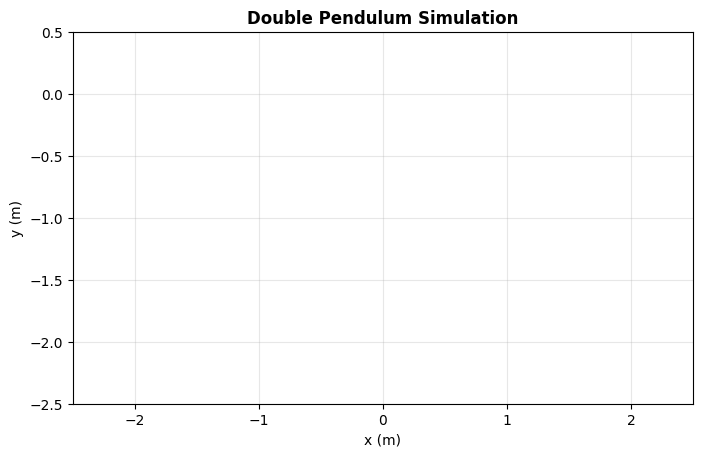

In [15]:
trajectory = np.zeros((t_steps, 4))
trajectory[0] = initial_state

for i in range(1, t_steps):
    trajectory[i] = rk4_step(trajectory[i-1], i*dt, dt)

# Extract angles
theta1 = trajectory[:, 0]
theta2 = trajectory[:, 1]

# Calculate positions
x1 = L1 * np.sin(theta1)
y1 = -L1 * np.cos(theta1)
x2 = x1 + L2 * np.sin(theta2)
y2 = y1 - L2 * np.cos(theta2)

# Create animation
fig, ax = plt.subplots(figsize=(8, 8))

# Set up the plot
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Double Pendulum Simulation', fontweight='bold')

# Initialize plot elements
line, = ax.plot([], [], 'o-', lw=3, color='blue', markersize=8)
trace, = ax.plot([], [], '-', lw=1, color='red', alpha=0.3)
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

# Store trace points
trace_x = []
trace_y = []

### Animation function

In [12]:
def animate(frame):
    # Plot pendulum
    line.set_data([0, x1[frame], x2[frame]], [0, y1[frame], y2[frame]])
    
    # Update trace (keep last 300 points)
    trace_x.append(x2[frame])
    trace_y.append(y2[frame])
    if len(trace_x) > 300:
        trace_x.pop(0)
        trace_y.pop(0)
    
    trace.set_data(trace_x, trace_y)
    
    # Update time
    time_text.set_text(f'Time: {frame*dt:.2f}s')
    
    return line, trace, time_text

### Create animation:

In [13]:
# Reduce frame count for faster gif, or use all frames
frames_to_use = min(1000, t_steps)  # Use up to 1000 frames for reasonable file size
frame_skip = max(1, t_steps // frames_to_use)

ani = animation.FuncAnimation(
    fig, animate,
    frames=range(0, t_steps, frame_skip),
    interval=50,
    blit=True,
    repeat=True
)

# Save as GIF
print("Saving animation as double_pendulum.gif...")
writer = PillowWriter(fps=20)
ani.save(f'double_pendulum) m1,l1={m1,L1},m2,l2={m2,L2},.gif', writer=writer)
print("Done! Saved to double_pendulum.gif")

plt.close()

Saving animation as double_pendulum.gif...
Done! Saved to double_pendulum.gif
